In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Food101_AI_Project/datasets/food-101.zip"

extract_path = "/content/Food101_AI_Project"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset Extracted Successfully")

✅ Dataset Extracted Successfully


In [4]:
import os

print(os.listdir("/content/Food101_AI_Project"))

['food-101']


In [5]:
print(os.listdir("/content/Food101_AI_Project/food-101"))

['.DS_Store', 'license_agreement.txt', 'images', 'meta', 'README.txt']


In [6]:
print(len(os.listdir("/content/Food101_AI_Project/food-101/images")))

102


In [7]:
print(os.listdir("/content/Food101_AI_Project/food-101/images")[:10])

['gnocchi', 'seaweed_salad', '.DS_Store', 'grilled_salmon', 'spring_rolls', 'prime_rib', 'ceviche', 'french_fries', 'croque_madame', 'ice_cream']


In [8]:
import os

items = sorted(os.listdir("/content/Food101_AI_Project/food-101/images"))

hidden = [x for x in items if x.startswith(".")]

print(hidden)

['.DS_Store']


In [9]:
import os

hidden_file = "/content/Food101_AI_Project/food-101/images/.DS_Store"

if os.path.exists(hidden_file):
    os.remove(hidden_file)
    print("✅ .DS_Store removed")

✅ .DS_Store removed


In [10]:
print(len(os.listdir("/content/Food101_AI_Project/food-101/images")))

101


In [11]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

dataset_path = "/content/Food101_AI_Project/food-101/images"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("✅ Dataset Loaded Successfully")

Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.
✅ Dataset Loaded Successfully


In [12]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

print("✅ Dataset Ready")

✅ Dataset Ready


In [13]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.


In [14]:
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)

In [15]:
dataset_temp = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = dataset_temp.class_names

import json

with open("/content/drive/MyDrive/Food101_AI_Project/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Total Classes:", len(class_names))
print("✅ class_names.json Saved Successfully")

Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Total Classes: 101
✅ class_names.json Saved Successfully


In [16]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

print("✅ Data Augmentation Ready")

✅ Data Augmentation Ready


In [17]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

print("✅ EfficientNetB0 Loaded")
print("Total Layers :", len(base_model.layers))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
✅ EfficientNetB0 Loaded
Total Layers : 238


In [18]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model = Sequential([

    Input(shape=(224,224,3)),

    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.3),

    Dense(101, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 101)            │       129,381 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [19]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

print("✅ Model Compiled")

✅ Model Compiled


In [20]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_initial.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

csv_logger = CSVLogger(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/training_log_initial.csv"
)

print("✅ Callbacks Ready")

✅ Callbacks Ready


In [21]:
dataset_temp = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

print(dataset_temp.class_names[:10])
print(len(dataset_temp.class_names))

Found 101000 files belonging to 101 classes.
Using 80800 files for training.
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']
101


In [22]:
for images, labels in dataset_temp.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels[:10])

(32, 224, 224, 3)
(32,)
tf.Tensor([36 20 55 75 67  7 24 42 21 68], shape=(10,), dtype=int32)


In [23]:
for images, labels in train_dataset.take(1):
    predictions = model(images, training=False)

    print("Prediction Shape :", predictions.shape)
    print("Prediction Sum   :", tf.reduce_sum(predictions[0]).numpy())
    print("Prediction Max   :", tf.reduce_max(predictions[0]).numpy())

Prediction Shape : (32, 101)
Prediction Sum   : 1.0
Prediction Max   : 0.02704235


In [ ]:
loss, acc = model.evaluate(validation_dataset, verbose=1)

print("Loss:", loss)
print("Accuracy:", acc)

632/632 ━━━━━━━━━━━━━━━━━━━━ 51s 80ms/step - accuracy: 0.0129 - loss: 4.6992
Loss: 4.6991868019104
Accuracy: 0.01292079221457243


In [24]:
print(base_model.input_shape)
print(base_model.input.dtype)

(None, 224, 224, 3)
float32


In [25]:
print(base_model)

<Functional name=efficientnetb0, built=True>


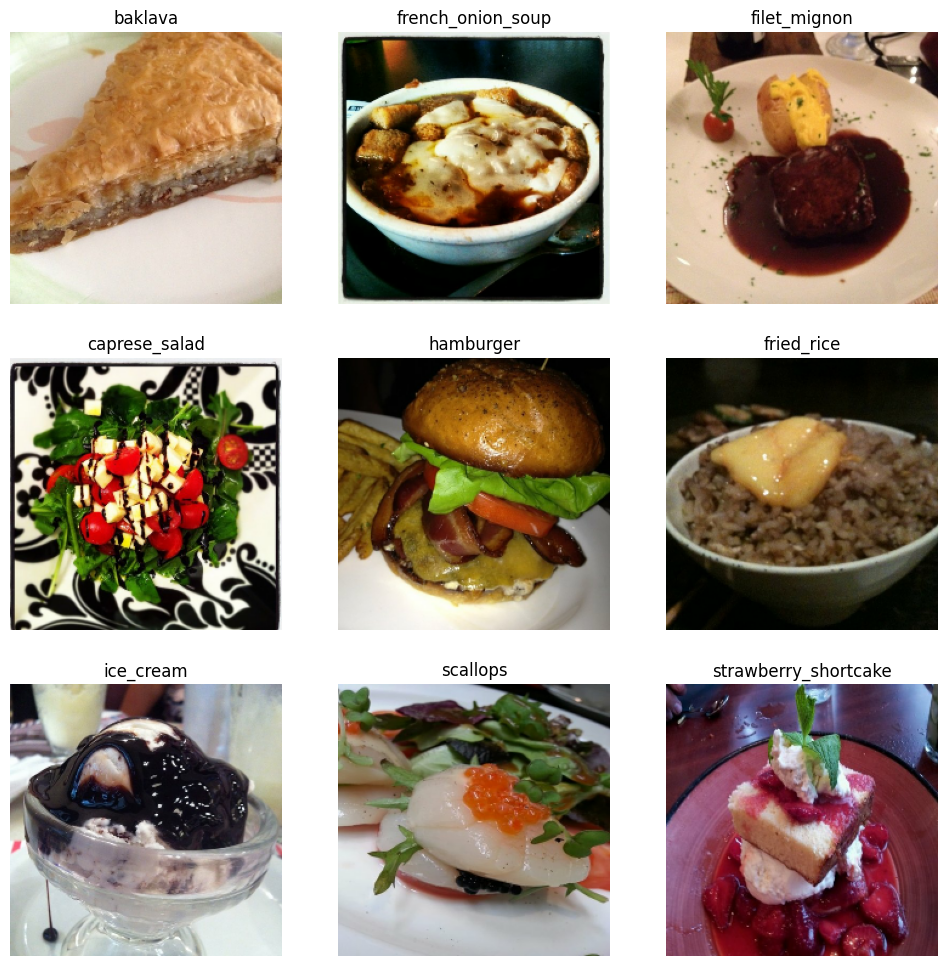

In [26]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12,12))

    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.show()

In [27]:
print(images.dtype)
print(tf.reduce_min(images).numpy())
print(tf.reduce_max(images).numpy())

<dtype: 'float32'>
0.0
255.0


In [28]:
model.layers

[<Sequential name=sequential, built=True>,
 <Functional name=efficientnetb0, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d, built=True>,
 <Dropout name=dropout, built=True>,
 <Dense name=dense, built=True>]

In [29]:
print(model.layers[1])
print(model.layers[2])
print(model.layers[3])

<Functional name=efficientnetb0, built=True>
<GlobalAveragePooling2D name=global_average_pooling2d, built=True>
<Dropout name=dropout, built=True>


In [30]:
base_model.summary()

Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=50,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr,
        csv_logger
    ],
    verbose=1
)

Epoch 1/50
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.3904 - loss: 2.6569
Epoch 1: val_accuracy improved from None to 0.61609, saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_initial.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_initial.keras
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 287s 108ms/step - accuracy: 0.4778 - loss: 2.1606 - val_accuracy: 0.6161 - val_loss: 1.4727 - learning_rate: 0.0010
Epoch 2/50
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5556 - loss: 1.7405
Epoch 2: val_accuracy improved from 0.61609 to 0.64248, saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_initial.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_initial.keras
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 265s 105ms/step - accuracy: 0.5614 - loss: 1.7191 - val_accuracy: 0.6425 - val_loss: 1.3589 - learnin

In [31]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_initial.keras",
    compile=False
)

print("✅ Initial Model Loaded")

✅ Initial Model Loaded


In [32]:
base_model = model.layers[1]

print(base_model.name)
print(len(base_model.layers))

efficientnetb0
238


In [33]:
base_model.trainable = True

for layer in base_model.layers[:-100]:
    layer.trainable = False

for layer in base_model.layers[-100:]:
    layer.trainable = True

print("✅ Last 100 Layers Unfrozen")

✅ Last 100 Layers Unfrozen


In [34]:
trainable = sum(layer.trainable for layer in base_model.layers)

print("Trainable Layers :", trainable)
print("Frozen Layers    :", len(base_model.layers) - trainable)

Trainable Layers : 100
Frozen Layers    : 138


In [35]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("✅ Fine-tuning Model Compiled")

✅ Fine-tuning Model Compiled


In [36]:
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

csv_logger = CSVLogger(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/training_log_100layers.csv"
)

print("✅ Fine-Tuning Callbacks Ready")

✅ Fine-Tuning Callbacks Ready


In [ ]:
history_finetune = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr,
        csv_logger
    ],
    verbose=1
)

Epoch 1/20
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.3800 - loss: 2.6223
Epoch 1: val_accuracy improved from None to 0.63520, saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 434s 162ms/step - accuracy: 0.4517 - loss: 2.2404 - val_accuracy: 0.6352 - val_loss: 1.4127 - learning_rate: 1.0000e-05
Epoch 2/20
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.5637 - loss: 1.6889
Epoch 2: val_accuracy improved from 0.63520 to 0.67203, saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 407s 161ms/step - accuracy: 0.5819 - loss: 1.6115 - val_accuracy: 0.6720 - val_loss: 1.

In [37]:
import os

print(os.path.exists("/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras"))
print(os.path.getsize("/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras"))

True
46489349


In [38]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_100layers.keras",
    compile=False
)

In [39]:
base_model = model.layers[1]

base_model.trainable = True

for layer in base_model.layers[:-150]:
    layer.trainable = False

for layer in base_model.layers[-150:]:
    layer.trainable = True

print("Trainable :", sum(layer.trainable for layer in base_model.layers))
print("Frozen :", len(base_model.layers) - sum(layer.trainable for layer in base_model.layers))

Trainable : 150
Frozen : 88


In [40]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=5e-6
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [41]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_150layers.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

csv_logger = CSVLogger(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/training_log_150layers.csv"
)

In [42]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [43]:
history_finetune_150 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr,
        csv_logger
    ],
    verbose=1
)

Epoch 1/15
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.7277 - loss: 0.9976
Epoch 1: val_accuracy improved from None to 0.75807, saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_150layers.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_150layers.keras
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 560s 208ms/step - accuracy: 0.7357 - loss: 0.9641 - val_accuracy: 0.7581 - val_loss: 0.9311 - learning_rate: 5.0000e-06
Epoch 2/15
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7458 - loss: 0.9275
Epoch 2: val_accuracy improved from 0.75807 to 0.76332, saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_150layers.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_150layers.keras
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 521s 206ms/step - accuracy: 0.7483 - loss: 0.9157 - val_accuracy: 0.7633 - val_loss: 0.

In [44]:
from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/Food101_AI_Project/saved_model/efficientnetb0_150layers.keras"
)

print("✅ Best Model Loaded")

✅ Best Model Loaded


In [45]:
import json

with open("/content/drive/MyDrive/Food101_AI_Project/class_names.json", "r") as f:
    class_names = json.load(f)

print("Total Classes:", len(class_names))
print(class_names[:10])

Total Classes: 101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


In [46]:
from google.colab import files

uploaded = files.upload()

Saving ice.jpg to ice.jpg


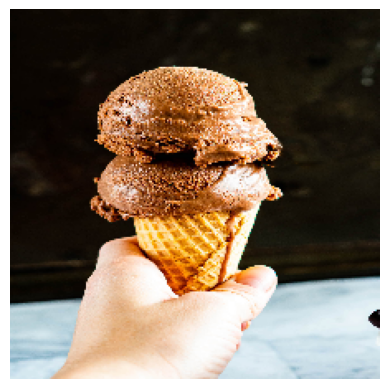

Image Shape: (1, 224, 224, 3)


In [47]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# Uploaded image path
img_path = "ice.jpg"

# Load image
img = image.load_img(img_path, target_size=(224, 224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.show()

# Convert to array
img_array = image.img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

print("Image Shape:", img_array.shape)

In [48]:
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

print("Predicted Class :", predicted_class)
print("Confidence      : {:.2f}%".format(confidence))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Predicted Class : ice_cream
Confidence      : 99.83%


In [49]:
top5 = np.argsort(predictions[0])[-5:][::-1]

print("Top 5 Predictions\n")

for i in top5:
    print(f"{class_names[i]:20} : {predictions[0][i]*100:.2f}%")

Top 5 Predictions

ice_cream            : 99.83%
macarons             : 0.07%
waffles              : 0.04%
cannoli              : 0.02%
beignets             : 0.01%


In [50]:
print("="*50)
print("Food Prediction Result")
print("="*50)

print(f"Predicted Food : {predicted_class.replace('_',' ').title()}")
print(f"Confidence     : {confidence:.2f}%")

print("\nTop 5 Predictions")

for i in top5:
    print(f"{class_names[i].replace('_',' ').title():25} {predictions[0][i]*100:.2f}%")

Food Prediction Result
Predicted Food : Ice Cream
Confidence     : 99.83%

Top 5 Predictions
Ice Cream                 99.83%
Macarons                  0.07%
Waffles                   0.04%
Cannoli                   0.02%
Beignets                  0.01%


In [51]:
from google.colab import files

uploaded = files.upload()

Saving 56135.jpg to 56135.jpg


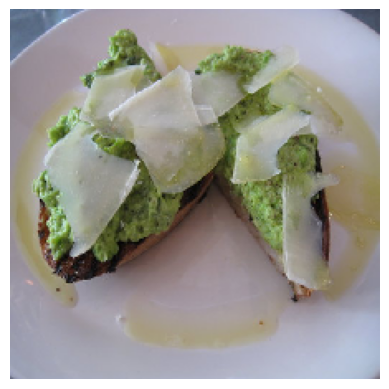

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [53]:
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

top5 = np.argsort(predictions[0])[-5:][::-1]

print("="*50)
print("Food Prediction Result")
print("="*50)

print(f"Predicted Food : {predicted_class.replace('_',' ').title()}")
print(f"Confidence     : {confidence:.2f}%")

print("\nTop 5 Predictions\n")

for i in top5:
    print(f"{class_names[i].replace('_',' ').title():25} {predictions[0][i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
Food Prediction Result
Predicted Food : Caesar Salad
Confidence     : 63.57%

Top 5 Predictions

Caesar Salad              63.57%
Beef Carpaccio            10.56%
Baklava                   4.61%
Ravioli                   4.33%
Peking Duck               3.72%


In [54]:
from google.colab import files

uploaded = files.upload()

Saving brush.jpg to brush.jpg


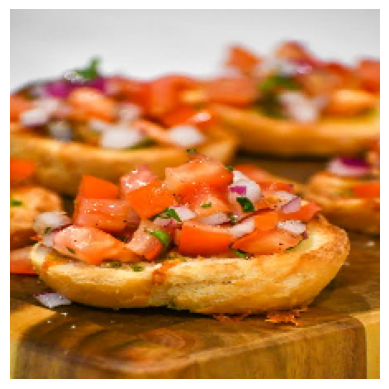

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [56]:
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

top5 = np.argsort(predictions[0])[-5:][::-1]

print("="*50)
print("Food Prediction Result")
print("="*50)

print(f"Predicted Food : {predicted_class.replace('_',' ').title()}")
print(f"Confidence     : {confidence:.2f}%")

print("\nTop 5 Predictions\n")

for i in top5:
    print(f"{class_names[i].replace('_',' ').title():25} {predictions[0][i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Food Prediction Result
Predicted Food : Bruschetta
Confidence     : 99.88%

Top 5 Predictions

Bruschetta                99.88%
Caprese Salad             0.02%
Greek Salad               0.01%
Ceviche                   0.01%
Shrimp And Grits          0.01%


In [57]:
from google.colab import files

uploaded = files.upload()

Saving pizza1.jpg to pizza1.jpg


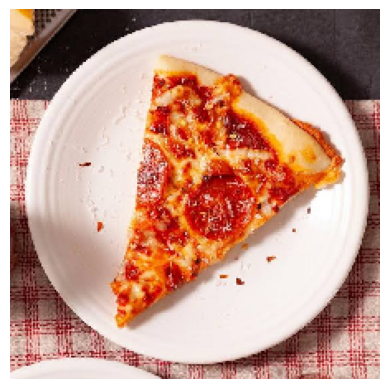

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [59]:
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

top5 = np.argsort(predictions[0])[-5:][::-1]

print("="*50)
print("Food Prediction Result")
print("="*50)

print(f"Predicted Food : {predicted_class.replace('_',' ').title()}")
print(f"Confidence     : {confidence:.2f}%")

print("\nTop 5 Predictions\n")

for i in top5:
    print(f"{class_names[i].replace('_',' ').title():25} {predictions[0][i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Food Prediction Result
Predicted Food : Pizza
Confidence     : 75.44%

Top 5 Predictions

Pizza                     75.44%
Lasagna                   20.33%
Ravioli                   2.11%
Apple Pie                 0.78%
Garlic Bread              0.37%


In [60]:
from google.colab import files

uploaded = files.upload()

Saving 22489.jpg to 22489.jpg


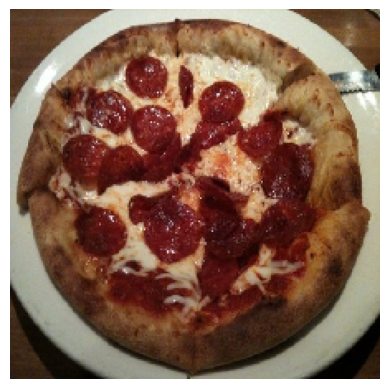

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [62]:
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

top5 = np.argsort(predictions[0])[-5:][::-1]

print("="*50)
print("Food Prediction Result")
print("="*50)

print(f"Predicted Food : {predicted_class.replace('_',' ').title()}")
print(f"Confidence     : {confidence:.2f}%")

print("\nTop 5 Predictions\n")

for i in top5:
    print(f"{class_names[i].replace('_',' ').title():25} {predictions[0][i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Food Prediction Result
Predicted Food : Pizza
Confidence     : 99.99%

Top 5 Predictions

Pizza                     99.99%
Bruschetta                0.00%
Nachos                    0.00%
Apple Pie                 0.00%
Beef Carpaccio            0.00%


In [63]:
from google.colab import files

uploaded = files.upload()

Saving carb_cake.jpg to carb_cake.jpg


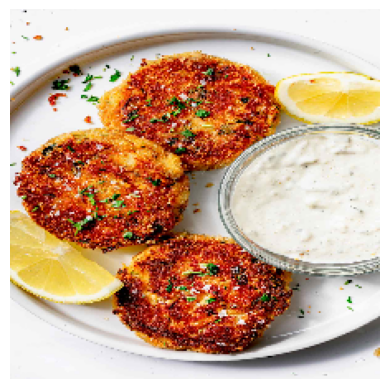

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224, 224))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

In [65]:
predictions = model.predict(img_array)

predicted_index = np.argmax(predictions[0])
predicted_class = class_names[predicted_index]
confidence = predictions[0][predicted_index] * 100

top5 = np.argsort(predictions[0])[-5:][::-1]

print("="*50)
print("Food Prediction Result")
print("="*50)

print(f"Predicted Food : {predicted_class.replace('_',' ').title()}")
print(f"Confidence     : {confidence:.2f}%")

print("\nTop 5 Predictions\n")

for i in top5:
    print(f"{class_names[i].replace('_',' ').title():25} {predictions[0][i]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Food Prediction Result
Predicted Food : Crab Cakes
Confidence     : 75.87%

Top 5 Predictions

Crab Cakes                75.87%
Ravioli                   8.85%
Spaghetti Bolognese       4.01%
Falafel                   2.82%
Grilled Salmon            2.73%
